In [3]:
import json 
import os 
import re 
from openai import OpenAI 

import pandas as pd
from tqdm import tqdm
from collections import Counter
from utils import get_completion, num_tokens_from_string, compute_token_price
import pickle

In [84]:
prompt = {"2_shot": """###Instructions###
Sei un esperto in giurisprudenza. Di seguito ti verranno mostrati un testo e una domanda.
Il tuo compito è stabilire se la risposta alla domanda è contenuta nel testo.
Ti verranno mostrati due esempi.
Il primo esempio indicato come ###ESEMPIO 1### mostra una risposta positiva.
Il secondo esempio, idicato come ###ESEMPIO 2### mostra una risposta negativa.
Puoi utilizzare solo i seguenti due OUTPUT validi: ["SI", "NO"].
L'OUTPUT è "SI" se la la risposta alla domanda è contenuta nel testo.
L'OUTPUT è "NO" se la risposta alla domanda non è contenuta nel testo.
Per poter dire "SI" la risposta alla domanda deve essere strettamente e chiaramente nel testo come mostrato dall' ESEMPIO 1.
Restituisci solamente "SI" o "NO" e null'altro.

###ESEMPIO 1###
Testo:
La capacità giuridica si acquista dal momento della nascita. I diritti che la legge riconosce a favore del concepito sono subordinati all'evento della nascita.

DOMANDA:
Quando si acquisice la capacità giuridica?

OUTPUT: SI

###ESEMPIO 2###
Testo:
La capacità giuridica si acquista dal momento della nascita. I diritti che la legge riconosce a favore del concepito sono subordinati all'evento della nascita.

DOMANDA:
Quali diritti sono riconsciuti per legge al concepito?

OUTPUT: NO

###TESTO INPUT###
{text}

###DOMANDA###
{query}

OUTPUT: """
}

In [ ]:
read_dir = "../manual_evaluation/evaluated_input"
man_eval_dfs = []
for el in os.listdir(read_dir):
    df = pd.read_csv(os.path.join(read_dir, el), sep = "\t").T.iloc[3:,:]
    man_eval_dfs.append(df)
    print(el)
full_df = pd.concat(man_eval_dfs).reset_index().rename({"index": "Testo", 0: "ManEval"}, axis = 1)
#replace NA, reducing responses to SI and NO to parse results for evaluation
full_df["ManEval"] = full_df["ManEval"].fillna("SI").apply(lambda x: str(x).split()[0][:2])

Form_Responses_man_eval_randss_14.tsv
Form_Responses_man_eval_randss_17.tsv
Form_Responses_man_eval_randss_18.tsv
Form_Responses_man_eval_randss_28.tsv
Form_Responses_man_eval_randss_3.tsv
Form_Responses_man_eval_randss_31.tsv
Form_Responses_man_eval_randss_35.tsv
Form_Responses_man_eval_randss_36.tsv
Form_Responses_man_eval_randss_39.tsv
Form_Responses_man_eval_randss_52.tsv
Form_Responses_man_eval_randss_76.tsv
Form_Responses_man_eval_randss_9.tsv


In [68]:
inputs = full_df.iloc[:,0].apply(lambda x: x.split("Domanda:")).tolist()
inputs[0]

['Art. 2357 quater Divieto di sottoscrizione delle proprie azioni In nessun caso la società può sottoscrivere azioni proprie. Le azioni sottoscritte in violazione del divieto stabilito nel precedente comma si intendono sottoscritte e devono essere liberate dai promotori e dai soci fondatori o, in caso di aumento del capitale sociale, dagli amministratori. La presente disposizione non si applica a chi dimostri di essere esente da colpa. Chiunque abbia sottoscritto in nome proprio, ma per conto della società, azioni di quest’ultima è considerato a tutti gli effetti sottoscrittore per conto proprio. Della liberazione delle azioni rispondono solidalmente, salvo che non dimostrino di essere esenti da colpa, i promotori, i soci fondatori e, nel caso di aumento del capitale sociale, gli amministratori.  ',
 ' In quali circostanze la disposizione riguardante la sottoscrizione di azioni proprie non si applica?']

In [123]:
66*1200 / 100

792.0

In [125]:
1200 - 792

408

In [89]:
formatted_prompts = []
for i in inputs:
    tmp_prompt = prompt["2_shot"]
    
    testo = i[0].strip().split("\n")[-1]
    domanda = i[-1].strip()

    formatted_prompts.append(tmp_prompt.replace("{text}", testo).replace("{query}", domanda))


In [100]:
print(formatted_prompts[0].split("###ESEMPIO 2###")[-1])


Testo:
La capacità giuridica si acquista dal momento della nascita. I diritti che la legge riconosce a favore del concepito sono subordinati all'evento della nascita.

DOMANDA:
Quali diritti sono riconsciuti per legge al concepito?

OUTPUT: NO

###TESTO INPUT###
Art. 2357 quater Divieto di sottoscrizione delle proprie azioni In nessun caso la società può sottoscrivere azioni proprie. Le azioni sottoscritte in violazione del divieto stabilito nel precedente comma si intendono sottoscritte e devono essere liberate dai promotori e dai soci fondatori o, in caso di aumento del capitale sociale, dagli amministratori. La presente disposizione non si applica a chi dimostri di essere esente da colpa. Chiunque abbia sottoscritto in nome proprio, ma per conto della società, azioni di quest’ultima è considerato a tutti gli effetti sottoscrittore per conto proprio. Della liberazione delle azioni rispondono solidalmente, salvo che non dimostrino di essere esenti da colpa, i promotori, i soci fondat

In [ ]:
# get model answers
answs = []
for p in tqdm(formatted_prompts):
    answs.append(get_completion(p, "gpt-4o"))

100%|██████████| 1200/1200 [10:56<00:00,  1.83it/s]


In [103]:
Counter(answs)

Counter({'SI': 982, 'NO': 218})

In [114]:
round(982/1200, 2)

0.82

In [119]:
round(1036/1200, 2)

0.86

In [178]:
full_df["ManEval"].value_counts()

ManEval
SI    1036
NO     164
Name: count, dtype: int64

In [ ]:
# adding the model 2-shot evaluations as a df columns
full_df["AutoEval_2shot"] = answs


In [179]:
full_df.to_csv("../manual_evaluation/man_auto_2hot_eval.tsv", sep = "\t")

In [109]:
from sklearn.metrics import classification_report, confusion_matrix

In [110]:
y = full_df["ManEval"]
y_hat = full_df["AutoEval_2shot"]
cm = confusion_matrix(y, y_hat)
print(classification_report(y, y_hat))

              precision    recall  f1-score   support

          NO       0.47      0.62      0.53       164
          SI       0.94      0.89      0.91      1036

    accuracy                           0.85      1200
   macro avg       0.70      0.75      0.72      1200
weighted avg       0.87      0.85      0.86      1200



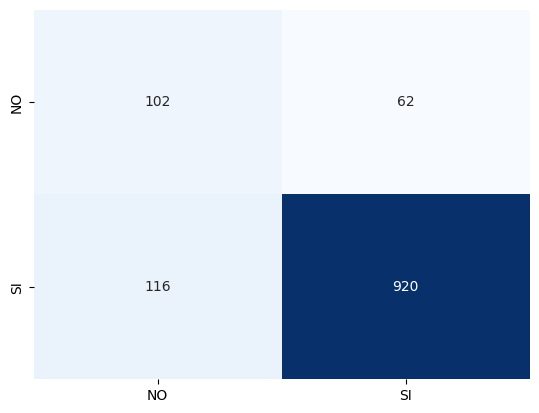

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, cmap = "Blues", cbar = False, annot = True, fmt = "g", yticklabels= ["NO", "SI"], xticklabels= ["NO","SI"]);

In [ ]:
import numpy as np
cm0 = np.array([[751, 258],
                [46, 118]])
cm0

array([[751, 258],
       [ 46, 118]])

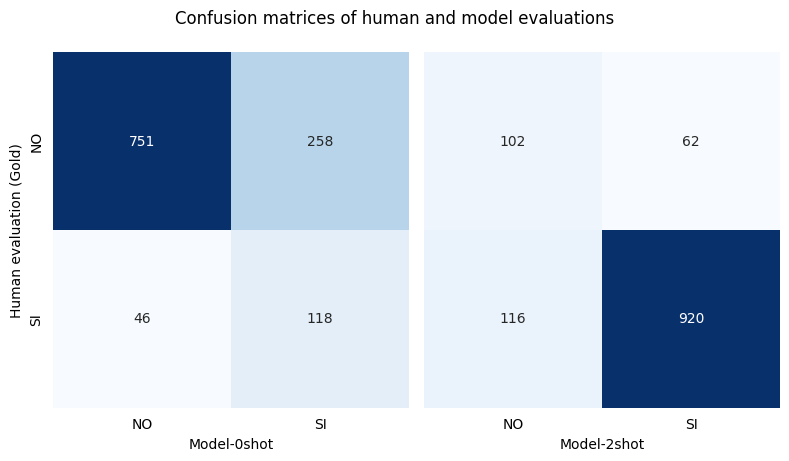

In [177]:
figure, axes  = plt.subplots(1, 2, figsize = (8, 6))
ax= sns.heatmap(cm0, cmap = "Blues", ax= axes[0], cbar = False, annot = True, square= True, fmt = "g", yticklabels= ["NO", "SI"], xticklabels= ["NO","SI"])
ax1 = sns.heatmap(cm, cmap = "Blues", ax= axes[1], cbar = False, annot = True, square= True, fmt = "g",  xticklabels= ["NO","SI"])
ax.set_xlabel("Model-0shot")
ax.tick_params(left=False, bottom=False)
ax.set_ylabel("Human evaluation (Gold)")
ax1.set_xlabel("Model-2shot")
ax1.tick_params(left=False, bottom=False)
ax1.set_yticklabels([])
plt.suptitle("Confusion matrices of human and model evaluations")

plt.tight_layout()
plt.subplots_adjust(top=1.2)
plt.show()

In [ ]:




eval_dfs = []
for n,book in enumerate(dfs, 1):
    print(f"Processing qas of book_{n}")

answ = []
for row in tqdm(book.itertuples()):
    query = re.sub(" secondo il testo?", "", row.Query[2:]).strip()
    passage = row.Passage.strip()
    prompt =  re.sub(r"\{query\}", query, re.sub(r"\{text\}", passage, evaluation_prompt))
    answ.append(re.sub(r"\"", "", get_completion(prompt, "gpt-4o")).strip())
    

print(f"\nResults for book {n}: {Counter(answ)}")
book["IsQueryRelevant"] = answ
eval_dfs.append(book)
book.to_csv(f"../automatic_eval_results/autoeval_qabook_{n}.tsv", sep = "\t")

with open("../automatic_eval_results/all_autoeval_dfs.pkl", "wb") as outfile:
    pickle.dump(eval_dfs, outfile)